# Scenario A2: Single Supplier — With REC (Net Generators)

**Description:** Single supplier mandate with a Renewable Energy Community.
All 9 participants (3 prosumers + 6 consumers) are members of REC_01.
Internal energy sharing is performed proportionally before external supplier
billing. Prosumers are modelled as **net generators** (RES only, no local load).

**Configuration:**
| Parameter | Value |
|---|---|
| Suppliers | 1 — SUP_A |
| Balancing Groups | 1 — BG_A (all 9 participants) |
| RECs | 1 — REC_01 (all 9 members, proportional sharing) |
| Prosumer type | **Net generator** (RES only, no local load) |
| REC incentives | Shared energy: 0.01 €/kWh · Self-consumption: 0.015 €/kWh |
| Settlement basis | Corrected meter readings after REC sharing |
| Battery | None |

**Research role:** Tests the value of a single community-wide REC under a
single-supplier mandate, where generators contribute purely as RES sources.

**Comparison pairs:**
- A2 vs A1 → incremental value of adding a REC (net generator case)
- A2 vs A2-mixed → how prosumer load inclusion changes REC sharing volume
- A2 vs A2-SplitBG → effect of splitting consumers and generators into separate BGs

## 1. Import Dependencies
Import the EnergyMarketOperations class which handles the complete market simulation pipeline.

In [ ]:
from energy_market_operations import EnergyMarketOperations

## 2. Initialize Pipeline
Load the scenario configuration from JSON and create the pipeline instance. The config specifies participants, suppliers, market prices, and network topology.

In [ ]:
CONFIG_FILE = "A2_single_supplier_with_rec.json"
pipe = EnergyMarketOperations(CONFIG_FILE, scenario_name="A2")

## 3. Run Full Pipeline
Execute the complete market simulation:
1. **Day-Ahead Market** - Schedule energy positions based on DA forecasts
2. **Intra-Day Market** - Adjust positions with updated ID forecasts  
3. **REC Settlement** - Proportional energy sharing within community
4. **Balancing Market** - Settle imbalances at dual pricing
5. **Supplier Billing** - Calculate final costs per participant

In [ ]:
pipe.run_all()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running full pipeline for: A2
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SCENARIO: A2
  System  : Single Supplier Mandate with REC - Scenario A2
  Period  : 2016-01-01 → 2016-12-31
  Suppliers    : 1
  Prosumers    : 3
  Consumers    : 6
  RECs         : 1  →  has_rec = True
  Battery      : False
✓ Prices loaded: (35136, 5)  from prices.csv
✓ Load actual : (35136, 153)
✓ RES actual  : (35136, 27)
✓ Load forecast DA: (35136, 9)
✓ RES  forecast DA: (35136, 3)
✓ Load forecast ID: (35136, 9)
✓ RES  forecast ID: (35136, 3)
✓ DA market: (35136, 8)
✓ ID market : (35136, 19)
⚠ Battery optimization: skipped (no battery in config)
✓ REC settlement: 1 REC(s) processed
✓ Balancing market: (35136, 31)
✓ Customer billing: (316224, 12)  (9 customers)
✓ Monthly aggregation: (12, 27)
✓ Profit/loss calculated

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 4. Financial Summary
Display aggregated financial results including total revenues, costs, and profit/loss for the supplier.

In [ ]:
pipe.summary()


  ANNUAL FINANCIAL SUMMARY – A2

  SUP_A (Supplier A):

    REVENUES:
      Energy Market Sales : €      174.61
      Balancing Rewards   : €      124.41
      Retail Sales        : €   31,628.26
      ────────────────────────────────────────────
      Total Revenue       : €   31,927.28

    COSTS:
      Market Purchases    : €    5,256.41
      Balancing Penalties  : €      126.82
      Retail Purchases     : €      764.65
      ────────────────────────────────────────────
      Total Costs          : €    6,147.87

    PROFIT/LOSS:
      Annual Total         : €   25,779.40
      Monthly Average      : €    2,148.28

    IMBALANCE:
      System Position      : LONG
      Total Imbalance      :        -0.03 MWh
      BG Actual Position   :       148.07 MWh
      BG Forecast Position :       148.10 MWh

    REC SHARING:
      Shared Energy        :        94.79 MWh



## 5. Financial Visualization
Plot breakdown of revenues and costs by category (DA purchases, ID adjustments, balancing costs, customer sales).

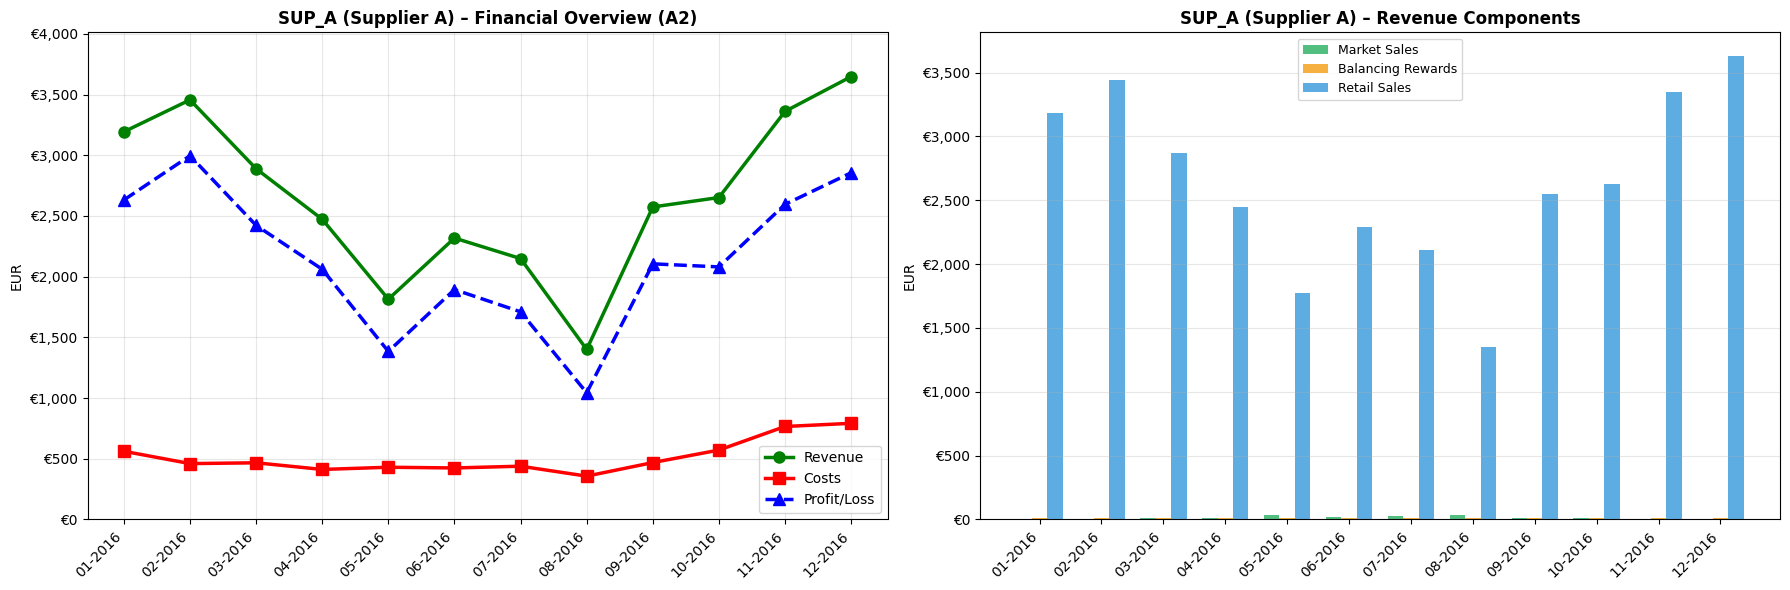

In [ ]:
pipe.plot_financials()

## 6. Imbalance Analysis
Visualize system imbalances over time showing the difference between scheduled positions and actual metered values.

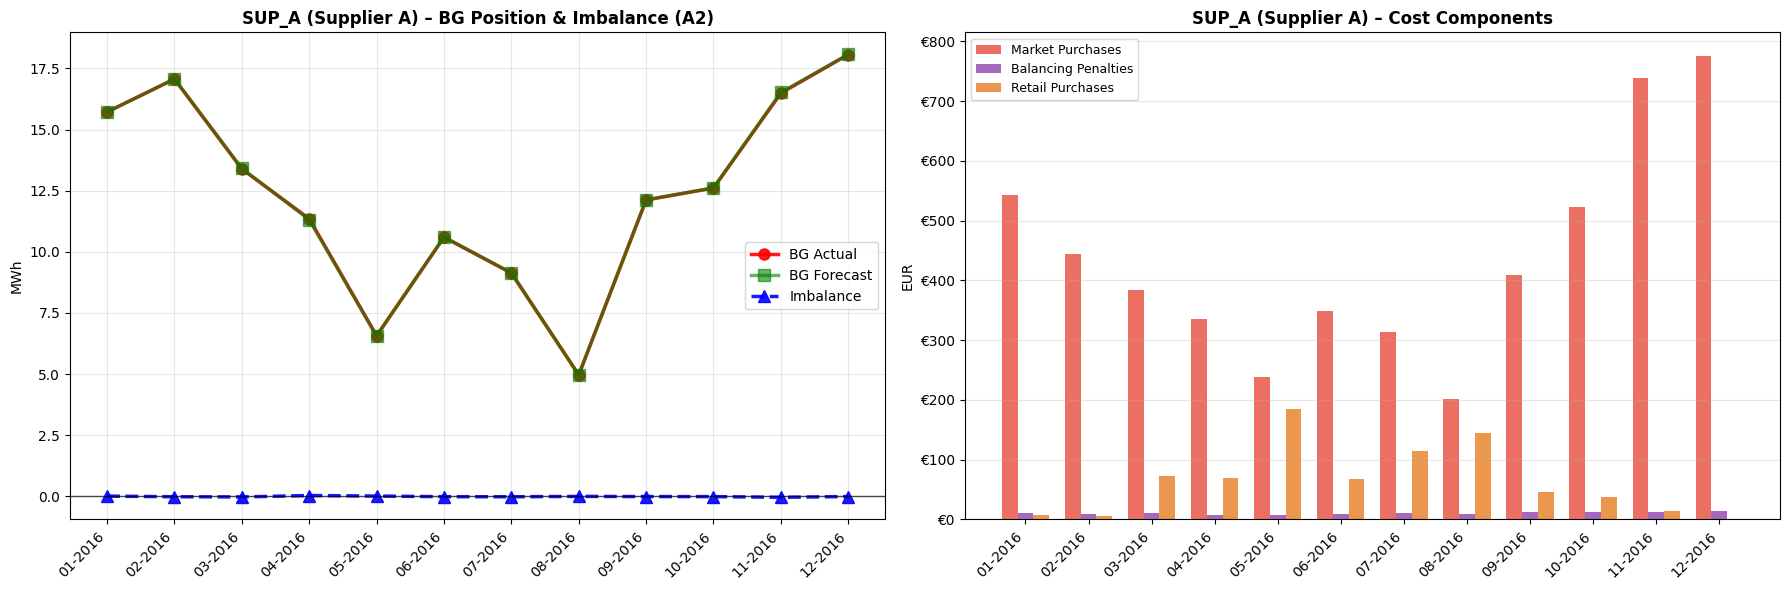

In [ ]:
pipe.plot_imbalances()

## 7. REC Analysis & Monthly Data
Display total energy shared within the REC and monthly analysis DataFrame with all financial metrics.

In [ ]:
print(f"Total Shared Energy: {pipe.es_monthly_analysis_df['internal_shared_energy_mwh'].sum():,.2f} MWh")
pipe.es_monthly_analysis_df

Total Shared Energy: 94.79 MWh


,datetime,supplier_id,balancing_group_id,da_net_load_forecast_mwh,da_net_gen_forecast_mwh,da_purchase_commitment_eur,da_sale_commitment_eur,id_net_load_adjustment_mwh,id_net_gen_adjustment_mwh,id_price_eur_per_mwh,...,internal_shared_energy_mwh,revenue_energy_market_sales_eur,revenue_balancing_rewards_eur,revenue_retail_sales_eur,total_revenue_eur,cost_energy_market_purchases_eur,cost_balancing_penalties_eur,cost_retail_purchases_eur,total_costs_eur,profit_loss_eur
0,01-2016,SUP_A,BG_A,17.534804,0.074518,602.287205,1.811660,-1.727604,0.024995,29.578424,...,3.059716,2.478887,11.040381,3179.845359,3193.364626,542.815519,10.798633,8.011995,561.626148,2631.738478
1,02-2016,SUP_A,BG_A,19.113312,0.062993,494.224656,0.965211,-1.956192,0.020716,22.414494,...,5.285122,1.290960,9.408886,3445.447829,3456.147675,443.812859,9.655817,6.597385,460.066061,2996.081614
2,03-2016,SUP_A,BG_A,16.025626,0.806665,429.903180,11.480715,-1.745369,0.066075,24.054382,...,8.535020,12.688161,8.843939,2867.425737,2888.957836,383.221195,11.218793,72.301376,466.741364,2422.216472
3,04-2016,SUP_A,BG_A,13.819510,0.742621,382.089802,13.216144,-1.670465,0.092896,25.278656,...,11.156758,14.967811,8.274284,2449.264660,2472.506755,335.799049,7.471267,68.588396,411.858712,2060.648042
4,05-2016,SUP_A,BG_A,10.110948,2.047542,272.915187,26.857367,-1.292920,0.214168,22.983915,...,11.782869,31.031988,10.230404,1773.056596,1814.318988,237.567627,7.273613,185.257366,430.098606,1384.220382
5,06-2016,SUP_A,BG_A,12.937683,0.722568,395.015066,13.361966,-1.514833,0.095236,27.656510,...,9.687867,15.586838,8.600737,2293.686704,2317.874279,348.447149,8.587418,67.151142,424.185709,1893.688570
6,07-2016,SUP_A,BG_A,12.014309,1.252057,358.617028,22.782130,-1.482460,0.135842,27.186418,...,11.549817,25.723590,9.785683,2113.569625,2149.078898,314.163841,10.440238,114.077485,438.681563,1710.397335
7,08-2016,SUP_A,BG_A,7.814928,1.565531,234.637014,32.655077,-1.076695,0.206404,27.340985,...,11.335763,37.856833,9.356591,1352.914007,1400.127431,202.357664,9.334706,145.109900,356.802271,1043.325161
8,09-2016,SUP_A,BG_A,14.277030,0.466742,461.816015,10.517047,-1.602977,0.082419,30.138160,...,9.453632,12.743029,12.623897,2548.748932,2574.115858,409.908983,12.575536,46.087879,468.572397,2105.543461
9,10-2016,SUP_A,BG_A,14.637671,0.380095,586.143957,12.841651,-1.570538,0.071757,36.803320,...,6.187062,15.300563,11.690392,2624.826152,2651.817107,522.770976,11.766778,37.050997,571.588751,2080.228356
